# 230 — Blob clustering

![image.png](attachment:2ae06b53-2ef7-4c2c-81f2-c99f94beed92.png)


Blob feature extraction → score gating → feature weighting → KMeans + HC clustering.

**Outputs** → `outputs/230_blob_clustering_runs/<run_id>/`

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sys.path.insert(0, str(Path('..').resolve()))

from functions import lf_blob_clustering_config as cfg
from functions.lf_blob_clustering import (
    s20_build_valley_features,
    s30_gate_by_blob_score,
    q31_plot_score_histograms,
    q32_plot_score_gating_grid,
    q33_plot_valley_overlay_grid,
)
from functions.lf_blob_metrics import s22_build_blob_feature_matrix, s23_init_blob_metric
from functions.lf_clustering import s10_load_ersps, s71_save_gated_blob_run
from functions.lf_clustering_methods import (
    s50_run_kmeans,
    s51_run_hc,
    s52_cut_hc,
    s53_compute_medoids,
    s55_build_df_with_clusters,
    s71_save_run,
    q50_plot_silhouette_curve,
    q51_plot_dendrogram,
    q52_plot_prototype_grid,
)

# ── output root ──────────────────────────────────────────────
BASE_RUNS_DIR = Path('outputs/230_blob_clustering_runs')
BASE_RUNS_DIR.mkdir(parents=True, exist_ok=True)

## Config

In [2]:
# ── data input ───────────────────────────────────────────────
INPUT_DIR = Path('../01_FBM_Analysis/outputs/04_ersp_LM_RAWONLY')
TASK      = 'LM'
CONDITIONS = ('audio', 'picture', 'reading')
N_FREQ, N_TIME = 129, 300

# ── segmentation ─────────────────────────────────────────────
VALLEY_PARAMS = cfg.VALLEY_PARAMS

# ── score gating ─────────────────────────────────────────────
BLOB_SCORE_QUANTILE  = cfg.BLOB_SCORE_QUANTILE
MANUAL_SCORE_THR     = None   # set a float to override quantile

# ── feature weighting ────────────────────────────────────────
FEATURE_TYPE_WEIGHTS = cfg.FEATURE_TYPE_WEIGHTS

# ── clustering ───────────────────────────────────────────────
KMEANS_K_RANGE = cfg.KMEANS_K_RANGE
HC_METHOD      = 'average'      # 'average', 'complete', 'ward'
HC_N_CLUSTERS  = 20             # cut HC at this K for comparison
RANDOM_STATE   = cfg.RANDOM_STATE

print('VALLEY_PARAMS:', VALLEY_PARAMS)
print('BLOB_SCORE_QUANTILE:', BLOB_SCORE_QUANTILE)
print('KMEANS_K_RANGE:', KMEANS_K_RANGE)

VALLEY_PARAMS: {'thr_pos': 2.5, 'thr_neg': -3.5, 'delta_valley': 1.5, 'min_mean_pos': 1.75, 'max_mean_neg': -2.8000000000000003, 'max_blobs': 6, 'sign_mode': 'both'}
BLOB_SCORE_QUANTILE: 0.9
KMEANS_K_RANGE: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25]


## 1 — Load ERSPs

In [3]:
df_meta, ersp_list = s10_load_ersps(
    input_dir=INPUT_DIR,
    task=TASK,
    allowed_conditions=CONDITIONS,
    n_freq=N_FREQ,
    n_time=N_TIME,
)
print(df_meta.shape, len(ersp_list))
df_meta.head()

Detected patient folders:
  - EL030
  - EL035
  - EL036
  - EL037
  - EL038
  - EL040
  - EL042
  - EL043
  - EL045

Total patients detected: 9

Patient EL030 — conditions found: ['audio', 'picture', 'reading']
  Loading 89 files from condition 'audio'
  Loading 89 files from condition 'picture'
  Loading 89 files from condition 'reading'

Patient EL035 — conditions found: ['audio', 'picture', 'reading']
  Loading 118 files from condition 'audio'
  Loading 118 files from condition 'picture'
  Loading 118 files from condition 'reading'

Patient EL036 — conditions found: ['audio', 'picture', 'reading']
  Loading 63 files from condition 'audio'
  Loading 63 files from condition 'picture'
  Loading 63 files from condition 'reading'

Patient EL037 — conditions found: ['audio', 'picture', 'reading']
  Loading 115 files from condition 'audio'
  Loading 115 files from condition 'picture'
  Loading 115 files from condition 'reading'

Patient EL038 — conditions found: ['audio', 'picture', 'readi

,sample_idx,patient_id,condition,task,electrode,file_path
0,0,EL030,audio,LM,A_L10,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
1,1,EL030,audio,LM,A_L11,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
2,2,EL030,audio,LM,A_L12,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
3,3,EL030,audio,LM,A_L13,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...
4,4,EL030,audio,LM,A_L14,..\01_FBM_Analysis\outputs\04_ersp_LM_RAWONLY\...


## 2 — Valley blob segmentation + feature extraction

In [4]:
X_blob, max_scores, blobs_per_sample = s22_build_blob_feature_matrix(
    ersp_list=ersp_list,
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    thr_pos=float(VALLEY_PARAMS['thr_pos']),
    thr_neg=float(VALLEY_PARAMS['thr_neg']),
    delta_valley=float(VALLEY_PARAMS['delta_valley']),
    min_mean_pos=float(VALLEY_PARAMS['min_mean_pos']),
    max_mean_neg=float(VALLEY_PARAMS['max_mean_neg']),
    sign_mode=str(VALLEY_PARAMS['sign_mode']),
)
print('X_blob:', X_blob.shape)
print('max_scores:', max_scores.shape, '  min/max:', max_scores.min(), max_scores.max())

Valley-blob feature matrix: X_blob.shape=(2625, 48) (max_blobs=6, features_per_blob=8)
X_blob: (2625, 48)
max_scores: (2625,)   min/max: 6.607211 31448.818


## 3 — Score gating

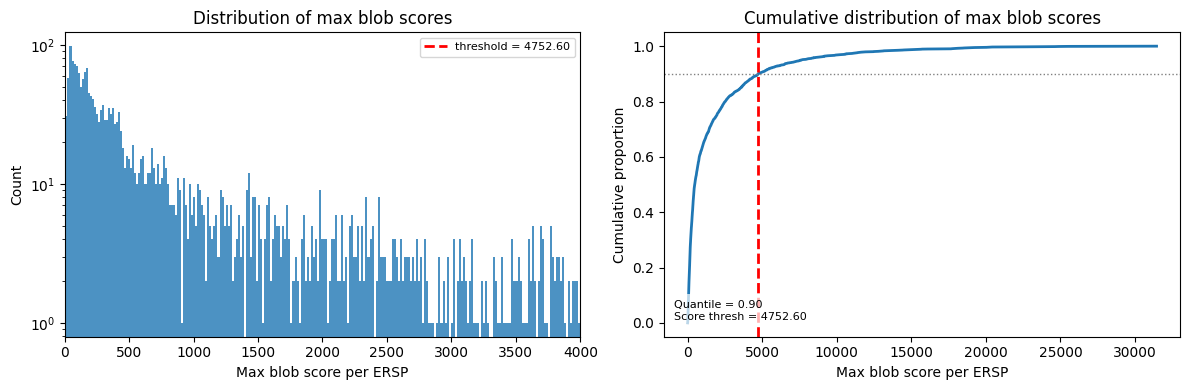

In [5]:
q31_plot_score_histograms(
    max_scores=max_scores,
    score_thresh=float(np.quantile(max_scores, BLOB_SCORE_QUANTILE)),
    quantile=BLOB_SCORE_QUANTILE,
)

In [6]:
(
    df_keep, ersp_keep, X_blob_keep,
    keep_idx, score_thr, keep_mask, drop_idx
) = s30_gate_by_blob_score(
    df_meta=df_meta.copy(),
    ersp_list=ersp_list,
    X_blob=X_blob,
    max_scores=max_scores,
    quantile=BLOB_SCORE_QUANTILE,
    manual_threshold=MANUAL_SCORE_THR,
)
print('Kept:', len(df_keep), '  Dropped:', len(drop_idx))

Score gating:
  quantile=0.90 → q_thresh=4752.600
  using score_thresh=4752.600 (from quantile)
  kept   : 263 ERSPs
  dropped: 2362 ERSPs
Kept: 263   Dropped: 2362


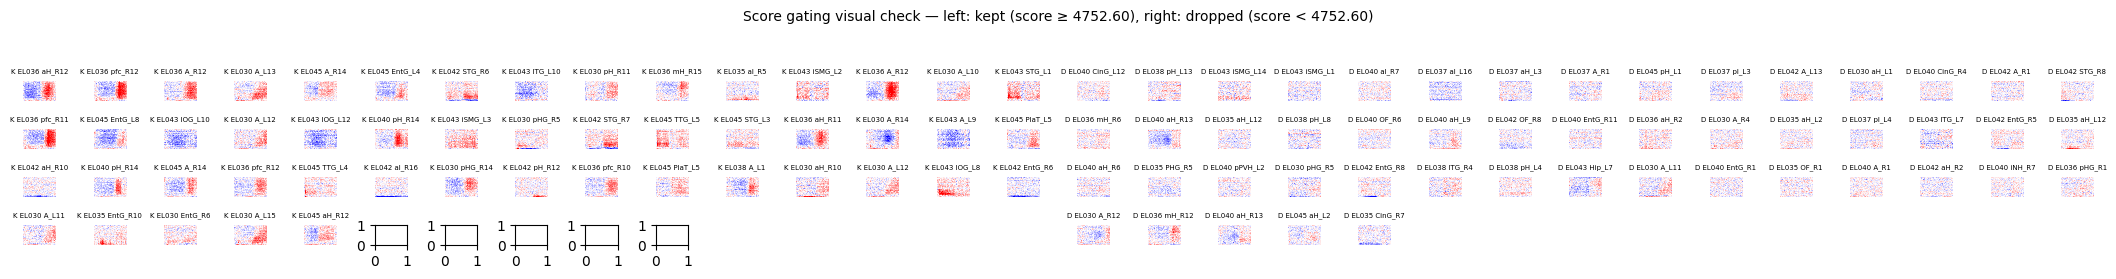

In [7]:
q32_plot_score_gating_grid(
    ersp_list_raw=ersp_list,
    df_meta_raw=df_meta,
    keep_idx=keep_idx,
    drop_idx=drop_idx,
    score_thresh=score_thr,
)

## 4 — Feature weighting

In [8]:
s23_init_blob_metric(
    max_blobs=int(VALLEY_PARAMS['max_blobs']),
    features_per_blob=8,
    feature_type_weights=FEATURE_TYPE_WEIGHTS,
)

# Build weight vector and apply
from functions.lf_blob_metrics import BLOB_WEIGHT_VEC
Xw = X_blob_keep * BLOB_WEIGHT_VEC
print('Xw:', Xw.shape)

[s23_init_blob_metric] 6 blobs × 8 features = 48D; weight_vec.shape=(48,)
Xw: (263, 48)


## 5 — KMeans clustering

In [9]:
labels_km, best_k, sil_by_k, labels_by_k = s50_run_kmeans(
    Xw=Xw,
    k_range=KMEANS_K_RANGE,
    random_state=RANDOM_STATE,
)

  K= 13  sil=0.1867
  K= 14  sil=0.1957
  K= 15  sil=0.1883
  K= 16  sil=0.1890
  K= 17  sil=0.1959
  K= 18  sil=0.2042
  K= 19  sil=0.1876
  K= 20  sil=0.1978
  K= 21  sil=0.2019
  K= 22  sil=0.2037
  K= 23  sil=0.2103
  K= 24  sil=0.1981
  K= 25  sil=0.2156

[KMeans] Best K=25  silhouette=0.2156


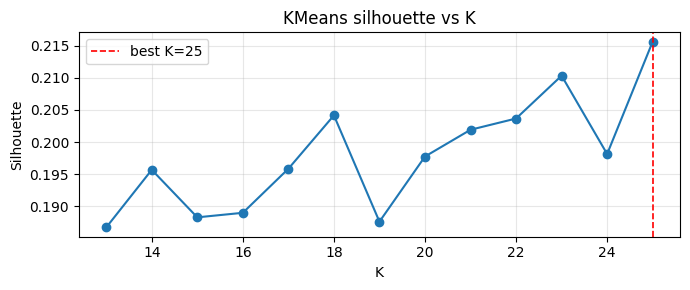

In [10]:
q50_plot_silhouette_curve(sil_by_k, best_k)

## 6 — Hierarchical clustering

In [11]:
Z, D = s51_run_hc(Xw, method=HC_METHOD)

[HC] method=average  metric=euclidean  n=263  cophenetic_r=0.557


\\nasac-m2.unige.ch\m-HumanNeuronLab\ANALYSIS\FLM\Analysis_LoraFanda\02_FBM_Clustering\functions\lf_clustering_methods.py:359: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


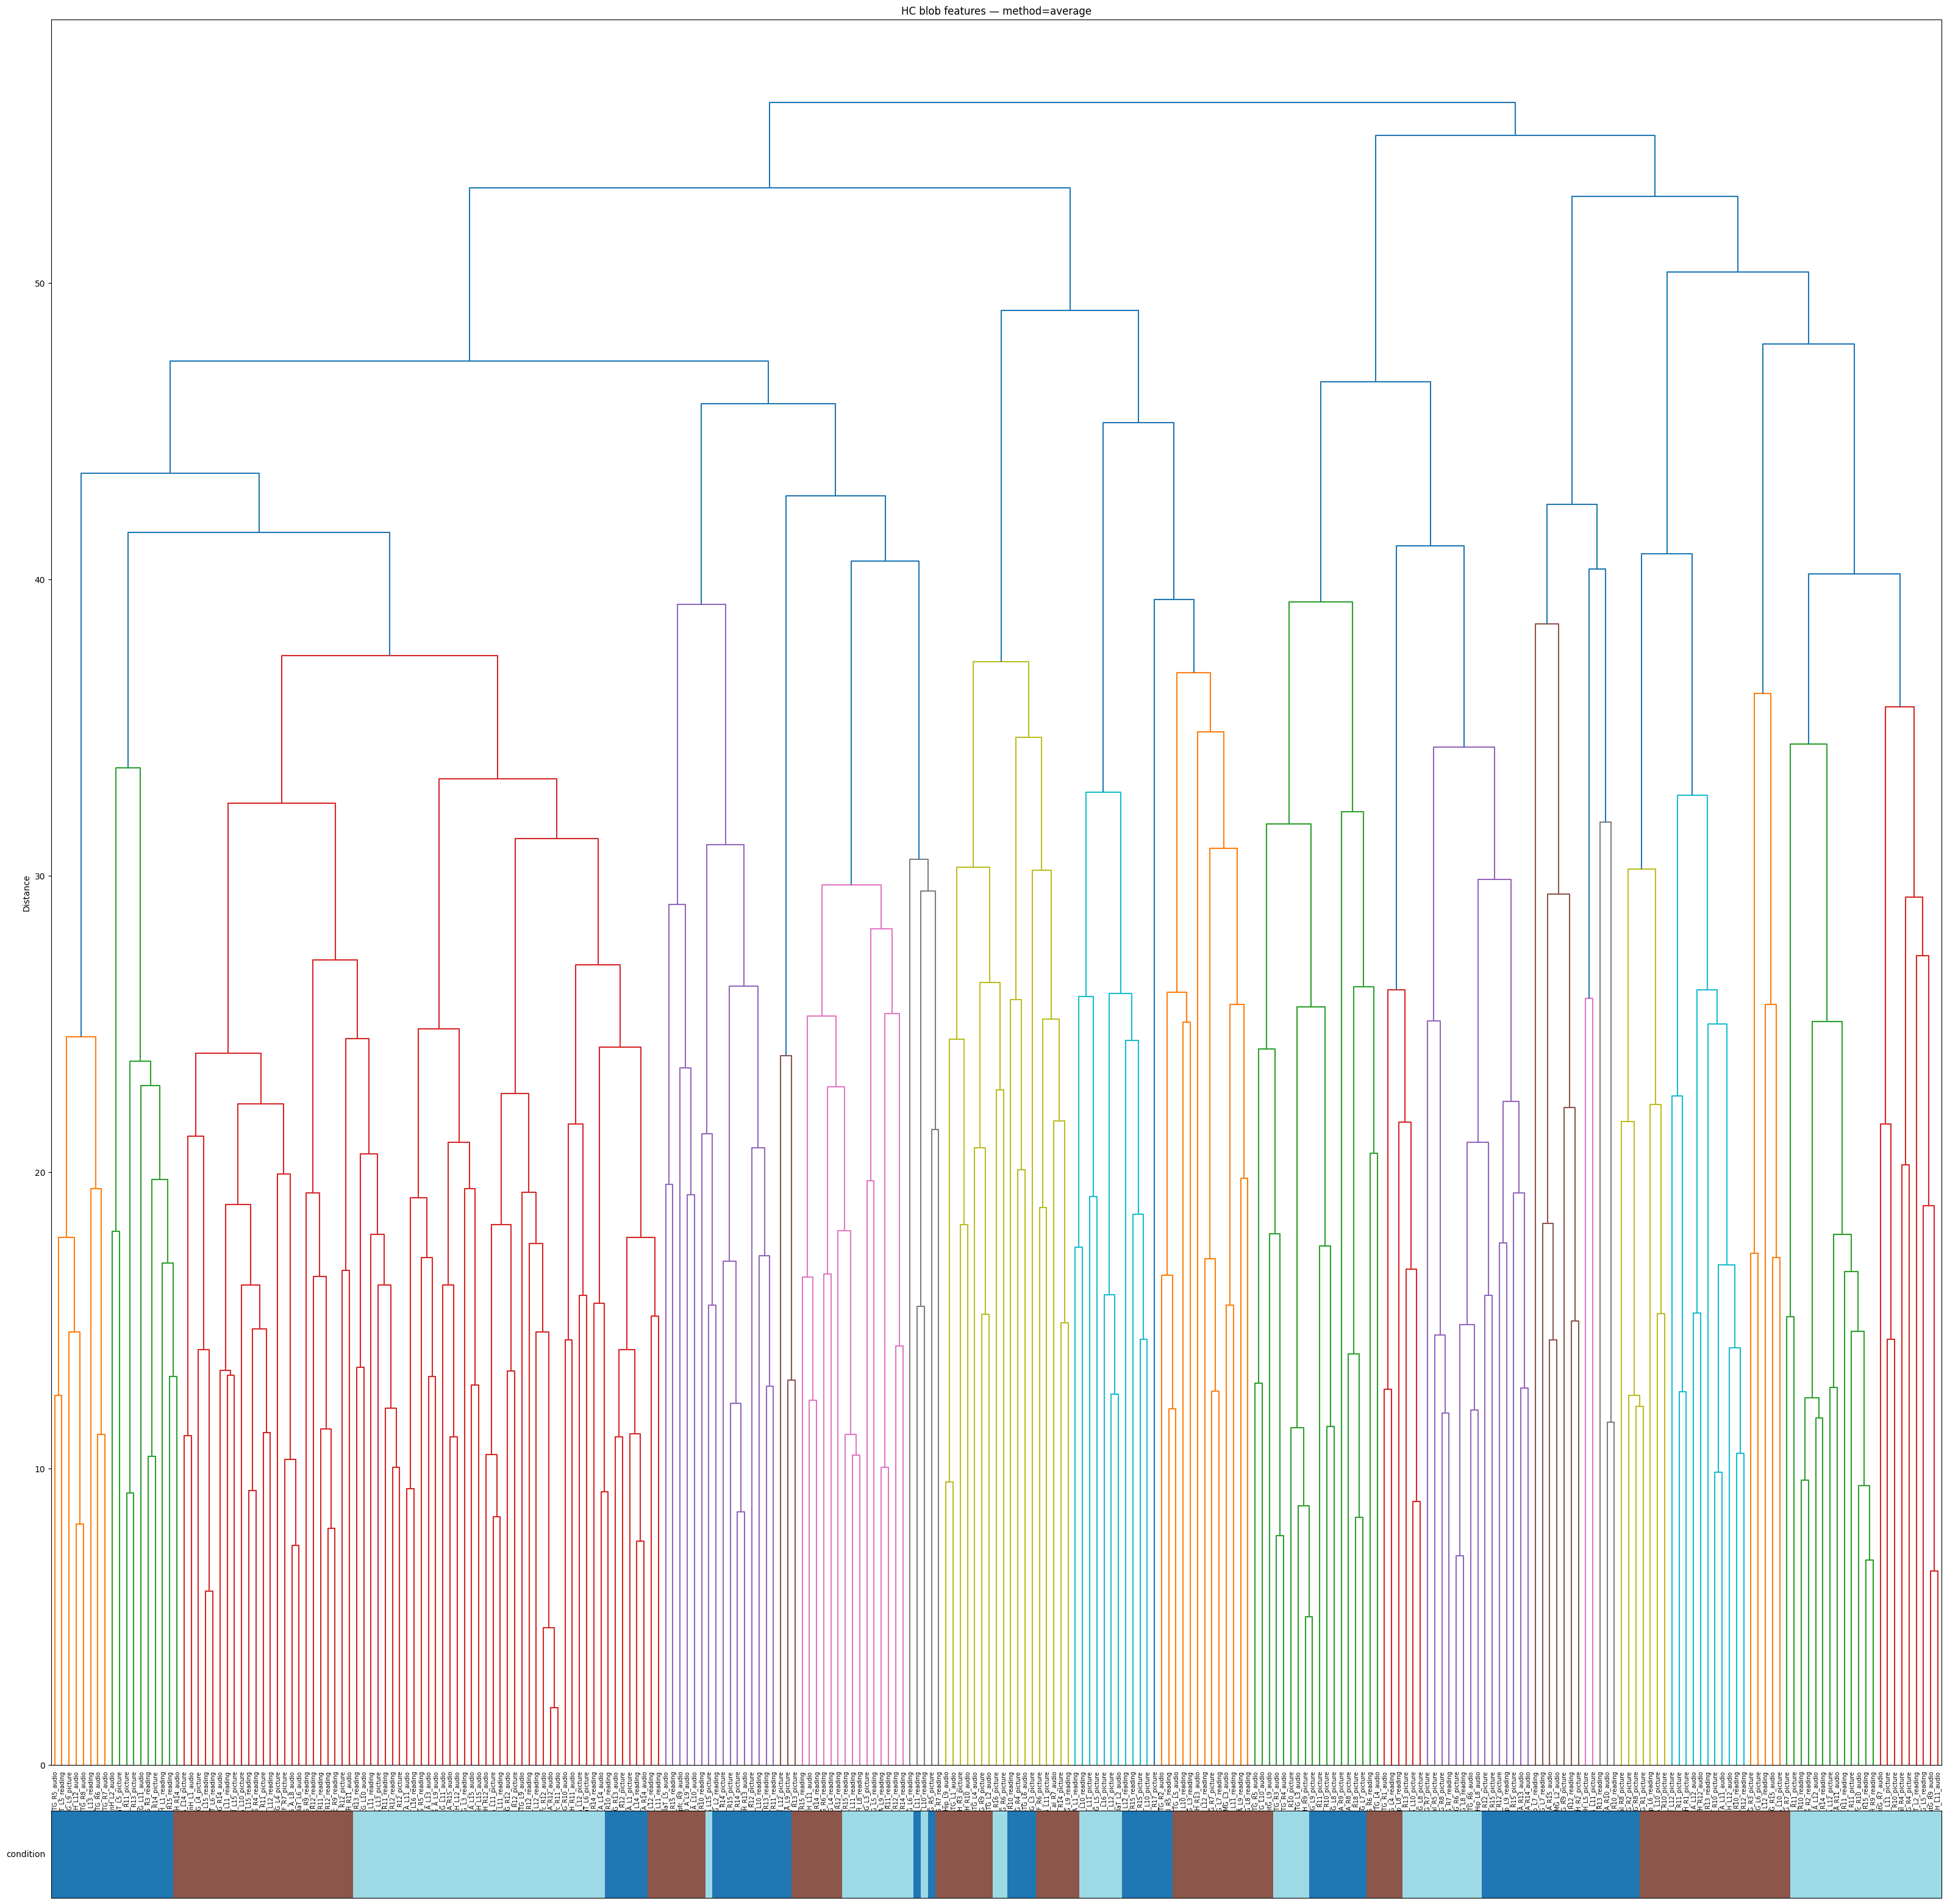

In [12]:
# Add leaf labels for dendrogram
df_keep['leaf_label'] = (
    df_keep['patient_id'].astype(str) + '_' +
    df_keep['electrode'].astype(str) + '_' +
    df_keep['condition'].astype(str)
)

q51_plot_dendrogram(
    Z=Z,
    df_leaf=df_keep,
    strip_col='condition',
    title=f'HC blob features — method={HC_METHOD}',
)

In [13]:
labels_hc = s52_cut_hc(Z, n_clusters=HC_N_CLUSTERS)
print('HC labels — unique clusters:', len(np.unique(labels_hc)))

HC labels — unique clusters: 20


## 7 — Medoids

In [14]:
medoids_km = s53_compute_medoids(D, labels_km)
medoids_hc = s53_compute_medoids(D, labels_hc)
print('KMeans medoids:', medoids_km)
print('HC medoids:', medoids_hc)

KMeans medoids: {0: 148, 1: 177, 2: 155, 3: 164, 4: 181, 5: 59, 6: 94, 7: 208, 8: 172, 9: 64, 10: 117, 11: 143, 12: 38, 13: 175, 14: 194, 15: 85, 16: 76, 17: 91, 18: 128, 19: 233, 20: 24, 21: 6, 22: 184, 23: 206, 24: 46}
HC medoids: {1: 155, 2: 76, 3: 215, 4: 208, 5: 229, 6: 43, 7: 193, 8: 35, 9: 138, 10: 249, 11: 80, 12: 233, 13: 6, 14: 177, 15: 27, 16: 92, 17: 31, 18: 143, 19: 17, 20: 99}


## 8 — Save run

In [15]:
# Save gated blob run first (X_blob_keep, df_keep, ersp_keep, scores)
run_dir = s71_save_gated_blob_run(
    base_runs_dir=BASE_RUNS_DIR,
    X_blob_keep=X_blob_keep,
    df_keep=df_keep,
    keep_idx=keep_idx,
    drop_idx=drop_idx,
    score_thr=score_thr,
    blob_score_quantile=BLOB_SCORE_QUANTILE,
    valley_params=VALLEY_PARAMS,
    ersp_keep=ersp_keep,
    max_scores=max_scores,
)
print('Run dir:', run_dir)

Saved gated blob run to:
outputs\230_blob_clustering_runs\20260416_214032
Files: 10
ERSP saved as: npy_stacked | shape: [263, 129, 300]
Run dir: outputs\230_blob_clustering_runs\20260416_214032


In [16]:
# KMeans cluster assignments
param_tag_km = f'k{best_k}_q{BLOB_SCORE_QUANTILE:.2f}'.replace('.', 'p')
df_km = s55_build_df_with_clusters(
    df_keep=df_keep,
    labels=labels_km,
    algo_tag='kmeans_blob',
    param_tag=param_tag_km,
    keep_idx=keep_idx,
)

s71_save_run(
    run_dir=run_dir,
    df_keep_with_clusters=df_km,
    labels=labels_km,
    algo_tag='kmeans_blob',
    param_tag=param_tag_km,
    sil_by_k=sil_by_k,
    labels_by_k=labels_by_k,
    extra_meta={'valley_params': VALLEY_PARAMS, 'feature_weights': FEATURE_TYPE_WEIGHTS},
)

[s71_save_run] Saved to: outputs\230_blob_clustering_runs\20260416_214032
  algo=kmeans_blob  param=k25_q0p90  n_clusters=25
  files in run_dir: 27


WindowsPath('outputs/230_blob_clustering_runs/20260416_214032')

In [17]:
# HC cluster assignments
param_tag_hc = f'k{HC_N_CLUSTERS}_{HC_METHOD}'
df_hc = s55_build_df_with_clusters(
    df_keep=df_keep,
    labels=labels_hc,
    algo_tag='hc_blob',
    param_tag=param_tag_hc,
    keep_idx=keep_idx,
)

s71_save_run(
    run_dir=run_dir,
    df_keep_with_clusters=df_hc,
    labels=labels_hc,
    algo_tag='hc_blob',
    param_tag=param_tag_hc,
    Z=Z,
    D=D,
    extra_meta={'valley_params': VALLEY_PARAMS, 'hc_method': HC_METHOD, 'hc_n_clusters': HC_N_CLUSTERS},
)
print('Done — run saved to:', run_dir)

[s71_save_run] Saved to: outputs\230_blob_clustering_runs\20260416_214032
  algo=hc_blob  param=k20_average  n_clusters=20
  files in run_dir: 30
Done — run saved to: outputs\230_blob_clustering_runs\20260416_214032
